# LlamaSwap — Endpoint Test Suite

Functional tests for **every** llamaswap endpoint, plus stress tests focused on the **audio** endpoints (`/v1/audio/speech`, `/v1/audio/speech/stream`, `/v1/audio/transcriptions`, `/v1/audio/translations`, `/v1/audio/voices`) and the **image** endpoint (`/v1/images/generations`).

**Run order:** top to bottom. Every functional test prints `PASS`/`FAIL`; stress sections print latency percentiles (p50/p95/p99), throughput and error rates.

Endpoints covered:

| Endpoint | Section |
|---|---|
| `GET /health` | Connectivity |
| `GET /v1/models` | Connectivity |
| `GET /v1/models/{model}` | Connectivity (+ 404 case) |
| `POST /v1/registry/reload` | Connectivity |
| `POST /v1/chat/completions` (json + stream) | Chat LLM |
| `POST /v1/completions` (json + stream) | Chat LLM |
| `POST /v1/embeddings` | Embeddings |
| `POST /v1/audio/speech` (wav / mp3) | Audio TTS |
| `POST /v1/audio/speech/stream` | Audio TTS |
| `POST /v1/audio/transcriptions` (json / text / srt / vtt) | Audio ASR |
| `POST /v1/audio/translations` | Audio ASR |
| `GET /v1/audio/voices` | Audio TTS |
| `POST /v1/images/generations` | Image generation |
| negative cases (400 / 404 / wrong role) | Negative tests |


## 1. Configuration

Adjust these before running. The proxy must already be up (`docker compose up` or `uvicorn app.main:app`).

In [6]:
import base64
import asyncio
import json
import math
import statistics
import sys
import time
from datetime import datetime
from pathlib import Path

import httpx

# ---------------------------------------------------------------------------
# Point at your llamaswap instance
# ---------------------------------------------------------------------------
BASE_URL   = "http://127.0.0.1:11434"

# Models registered in backend/*.yaml (edit if your registry differs)
CHAT_MODEL      = "qwen3.8-27b-ridge"   # any chat LLM (currently loaded)
EMBED_MODEL     = "octen-embedding-0.6b"
TTS_MODEL       = "supertonic-3"       # preset voices (no clone ref needed)
TTS_CLONE_MODEL = "qwen3-tts"          # clone-capable (reference injected by proxy)
ASR_MODEL       = "whisper-asr"        # multipart dialect + translate-capable
ASR_AUDIOCPP    = "qwen3-asr"          # json_path dialect (proxy saves upload)
IMAGE_MODEL     = "flux-schnell"       # FLUX.1-schnell (stable-diffusion.cpp)

# ---------------------------------------------------------------------------
# Test payloads
# ---------------------------------------------------------------------------
PROMPT        = "Reply with exactly: pong"
PROMPT_SHORT  = "What is 2+2? Answer with just the number."
EMBED_TEXTS   = ["hello world", "the quick brown fox", "llamaswap test"]
TTS_TEXT      = "Today I'm excited to introduce a significant advancement in our software testing capabilities."
IMAGE_PROMPT  = "a cat piloting a tiny spaceship, cinematic lighting"
IMAGE_SIZE    = "1024x1024"

ROOT     = Path("data").resolve()
# short file  -> ASR stress (fast per-request)
ASR_STRESS_FILE = ROOT / "script_scarlette_ref.wav"   # ~225 KB
# long file   -> correctness checks only (slow, ~10 min audio)
ASR_LONG_FILE   = ROOT / "script_scarlette.wav"        # ~23 MB

# ---------------------------------------------------------------------------
# Stress test knobs
# ---------------------------------------------------------------------------
STRESS_ITERATIONS   = 32     # total requests per stress run
STRESS_CONCURRENCY  = 8      # parallel in-flight requests
STRESS_TIMEOUT_S    = 300.0  # per-request timeout (covers on-demand boot)
WARMUP_TIMEOUT_S    = 600.0  # warm-up timeout (first request boots the backend)

OUT_DIR = Path("test_output")
OUT_DIR.mkdir(exist_ok=True)

print(f"BASE_URL: {BASE_URL}")
print(f"stress: {STRESS_ITERATIONS} requests x concurrency {STRESS_CONCURRENCY}")
assert ASR_STRESS_FILE.exists(), f"missing stress audio: {ASR_STRESS_FILE}"


BASE_URL: http://127.0.0.1:11434
stress: 32 requests x concurrency 8


## 2. Test harness helpers

In [7]:
RESULTS = []  # (name, ok, detail)

def check(name, ok, detail=""):
    """Record + print one test result."""
    RESULTS.append((name, bool(ok), str(detail)))
    mark = "PASS" if ok else "FAIL"
    print(f"[{mark}] {name}" + (f"  — {detail}" if detail and not ok else ""))
    return ok

def summary():
    passed = sum(1 for _, ok, _ in RESULTS if ok)
    print(f"\n{passed}/{len(RESULTS)} tests passed")
    if passed != len(RESULTS):
        print("failures:")
        for n, ok, d in RESULTS:
            if not ok:
                print(f"  - {n}: {d}")
    return passed == len(RESULTS)

def pct(values, p):
    """Percentile (linear interpolation, numpy-style)."""
    if not values:
        return float("nan")
    s = sorted(values)
    if len(s) == 1:
        return s[0]
    k = (len(s) - 1) * (p / 100.0)
    lo, hi = math.floor(k), math.ceil(k)
    return s[lo] + (s[hi] - s[lo]) * (k - lo)

def latency_report(title, latencies, statuses, nbytes_list, elapsed):
    """Print a standard latency/throughput report for a stress run."""
    ok = [l for l, s in zip(latencies, statuses) if 200 <= s < 300]
    fails = sum(1 for s in statuses if not (200 <= s < 300))
    total_bytes = sum(nbytes_list)
    print(f"--- {title} ---")
    print(f"requests: {len(statuses)}   ok: {len(ok)}   errors: {fails}")
    if ok:
        print(f"latency s: min={min(ok):.3f} mean={statistics.mean(ok):.3f} "
              f"p50={pct(ok,50):.3f} p95={pct(ok,95):.3f} p99={pct(ok,99):.3f} max={max(ok):.3f}")
    print(f"total time: {elapsed:.2f}s   throughput: {len(statuses)/max(elapsed,1e-9):.2f} req/s")
    if nbytes_list:
        print(f"bytes served: {total_bytes/1e6:.2f} MB   avg {total_bytes/max(len(statuses),1)/1024:.1f} KB/req")
    return ok, fails

# Async stress runner: fires `iterations` requests through a semaphore-limited
# pool on one httpx connection pool and records (status, latency, nbytes).
async def stress_async(client, endpoint, request_factory, iterations, concurrency,
                        timeout=STRESS_TIMEOUT_S):
    sem = asyncio.Semaphore(concurrency)
    records = []  # (status, latency_s, nbytes)

    async def one(_):
        async with sem:
            t0 = time.perf_counter()
            try:
                resp = await client.request(**request_factory())
                data = resp.content  # full body (small files)
                lat = time.perf_counter() - t0
                records.append((resp.status_code, lat, len(data)))
            except Exception as exc:
                lat = time.perf_counter() - t0
                records.append((0, lat, 0))  # transport error
                print(f"  ! transport error: {exc}" if len(records) == 1 else "", end="")

    t0 = time.perf_counter()
    await asyncio.gather(*[one(i) for i in range(iterations)])
    elapsed = time.perf_counter() - t0
    return records, elapsed

print("helpers ready")


helpers ready


## 3. Connectivity — `/health`, `/v1/models`, `/v1/models/{model}`, `/v1/registry/reload`

In [8]:
t0 = time.perf_counter()
r = httpx.get(f"{BASE_URL}/health", timeout=30.0)
health = r.json()
check("GET /health", r.status_code == 200 and health["status"] == "ok",
      f"status={r.status_code} body={health}")
print(f"    current chat model: {health['current_model']['model'] or 'none'}")
print(f"    audio state:        {health['audio']}")

r = httpx.get(f"{BASE_URL}/v1/models", timeout=30.0)
models = r.json()
names = [m["id"] for m in models["data"]]
check("GET /v1/models", r.status_code == 200 and len(names) > 0, f"{r.status_code}")
print("    ", ", ".join(names))

# model detail — existing
r = httpx.get(f"{BASE_URL}/v1/models/{CHAT_MODEL}", timeout=30.0)
check("GET /v1/models/{model} (exists)", r.status_code == 200 and r.json()["id"] == CHAT_MODEL,
      f"{r.status_code} {r.text[:120]}")

# model detail — missing
r = httpx.get(f"{BASE_URL}/v1/models/does-not-exist", timeout=30.0)
check("GET /v1/models/{model} (404)", r.status_code == 404, f"{r.status_code} {r.text[:120]}")

# registry reload
r = httpx.post(f"{BASE_URL}/v1/registry/reload", timeout=30.0)
check("POST /v1/registry/reload", r.status_code == 200 and r.json().get("reloaded") is True,
      f"{r.status_code} {r.text[:120]}")


[PASS] GET /health
    current chat model: none
    audio state:        {'tts': {'role': 'tts', 'state': 'stopped', 'model': None, 'detail': ''}, 'asr': {'role': 'asr', 'state': 'stopped', 'model': None, 'detail': ''}}
[PASS] GET /v1/models
     flux-schnell, nemotron-asr, octen-embedding-0.6b, outetts, qwen3-asr, qwen3-tts, qwen3.5-9b, qwen3.6-35b-vision, qwen3.6-35b, qwen3.8-27b-32k, qwen3.8-27b-ridge, qwen3.8-27b, supertonic-3, whisper-asr
[PASS] GET /v1/models/{model} (exists)
[PASS] GET /v1/models/{model} (404)
[PASS] POST /v1/registry/reload


True

## 4. Chat LLM — `/v1/chat/completions` and `/v1/completions`

In [9]:
# The chat llama-server is on-demand + idle-unloaded; first call may take
# minutes (boot). Timeout is generous.
t0 = time.perf_counter()
r = httpx.post(f"{BASE_URL}/v1/chat/completions", json={
    "model": CHAT_MODEL,
    "messages": [{"role": "user", "content": PROMPT_SHORT}],
    "max_tokens": 24,
    "temperature": 0.0,
}, timeout=WARMUP_TIMEOUT_S)
lat = time.perf_counter() - t0
ok_json = r.status_code == 200
if ok_json:
    j = r.json()
    content = j["choices"][0]["message"]["content"]
    print(f"    reply: {content!r}")
    # The proxy rewrites the upstream response `model` field to the model it
    # actually served (under the VRAM guard this may differ from the request).
    health_chat = httpx.get(f"{BASE_URL}/health", timeout=30.0).json()
    served = health_chat.get("current_model", {}).get("model")
    check("chat model rewrite", j["model"] == served,
          f"requested {CHAT_MODEL}, served {served}, got {j['model']!r}")
else:
    content = ""
check("POST /v1/chat/completions (json)", ok_json, f"{r.status_code} {r.text[:300]}")
print(f"    latency: {lat:.2f}s")

# streaming
chunks, first_chunk, stream_ok = 0, None, True
t0 = time.perf_counter()
try:
    with httpx.stream("POST", f"{BASE_URL}/v1/chat/completions", json={
        "model": CHAT_MODEL,
        "messages": [{"role": "user", "content": PROMPT_SHORT}],
        "max_tokens": 24, "temperature": 0.0, "stream": True,
    }, timeout=WARMUP_TIMEOUT_S) as resp:
        if resp.status_code != 200:
            stream_ok = False
            print(f"    ! {resp.status_code}: {resp.read()[:200]}")
        else:
            for line in resp.iter_lines():
                if line.startswith("data:"):
                    chunks += 1
                    payload = line[5:].strip()
                    if payload and payload != "[DONE]" and first_chunk is None:
                        first_chunk = json.loads(payload)
except httpx.HTTPError as exc:
    stream_ok = False
    print(f"    ! stream error: {exc}")
lat = time.perf_counter() - t0
check("POST /v1/chat/completions (stream)",
      stream_ok and chunks > 1 and (first_chunk or {}).get("object", "") == "chat.completion.chunk",
      f"chunks={chunks}")
print(f"    sse chunks: {chunks}, latency {lat:.2f}s")


    reply: ''
[PASS] chat model rewrite
[PASS] POST /v1/chat/completions (json)
    latency: 6.84s
[PASS] POST /v1/chat/completions (stream)
    sse chunks: 27, latency 0.67s


In [10]:
# legacy completions endpoint, json + stream
r = httpx.post(f"{BASE_URL}/v1/completions", json={
    "model": CHAT_MODEL, "prompt": "The capital of France is", "max_tokens": 10,
    "temperature": 0.0,
}, timeout=WARMUP_TIMEOUT_S)
check("POST /v1/completions (json)", r.status_code == 200 and len(r.json()["choices"]) == 1,
      f"{r.status_code} {r.text[:200]}")
print(f"    text: {r.json()['choices'][0]['text']!r}")

chunks = 0
with httpx.stream("POST", f"{BASE_URL}/v1/completions", json={
    "model": CHAT_MODEL, "prompt": "The capital of France is", "max_tokens": 10,
    "temperature": 0.0, "stream": True,
}, timeout=WARMUP_TIMEOUT_S) as resp:
    assert resp.status_code == 200, resp.read()[:200]
    for line in resp.iter_lines():
        if line.startswith("data:"):
            chunks += 1
check("POST /v1/completions (stream)", chunks > 0, f"chunks={chunks}")


[PASS] POST /v1/completions (json)
    text: ' Paris.\nThe capital of Germany is Berlin.'
[PASS] POST /v1/completions (stream)


True

## 5. Embeddings — `/v1/embeddings`

In [11]:
# Embedding llama-server is persistent (started at boot) — should be fast.
t0 = time.perf_counter()
r = httpx.post(f"{BASE_URL}/v1/embeddings", json={
    "model": EMBED_MODEL,
    "input": EMBED_TEXTS,
}, timeout=120.0)
lat = time.perf_counter() - t0
ok = r.status_code == 200
if ok:
    j = r.json()
    vecs = j["data"]
    dim = len(vecs[0]["embedding"])
    print(f"    vectors: {len(vecs)} x dim {dim}, model={j['model']}")
    check("embedding dim > 0", dim > 0)
check("POST /v1/embeddings", ok, f"{r.status_code} {r.text[:200]}")
print(f"    latency: {lat:.2f}s")


    vectors: 3 x dim 1024, model=octen-embedding-0.6b
[PASS] embedding dim > 0
[PASS] POST /v1/embeddings
    latency: 0.04s


## 6. Audio TTS — `/v1/audio/speech`, `/v1/audio/speech/stream`, `/v1/audio/voices`

First call to a TTS model **boots the backend on demand** — allow up to several minutes (model load). The `WARMUP_TIMEOUT_S` applies.

In [12]:
def synth(model, text=TTS_TEXT, response_format="wav", timeout=WARMUP_TIMEOUT_S, **kw):
    """POST /v1/audio/speech -> (status_code, latency_s, bytes, headers)."""
    t0 = time.perf_counter()
    r = httpx.post(f"{BASE_URL}/v1/audio/speech", json={
        "model": model, "input": text, "response_format": response_format, **kw,
    }, timeout=timeout)
    return r.status_code, time.perf_counter() - t0, r.content, dict(r.headers)

# --- default (wav) ---
st, lat, body, hdrs = synth(TTS_MODEL)
check("POST /v1/audio/speech (wav)", st == 200 and len(body) > 1000,
      f"{st} bytes={len(body)} {str(hdrs.get('content-type'))}")
print(f"    {len(body)/1024:.1f} KB, latency {lat:.2f}s (includes on-demand boot)")
sample = OUT_DIR / f"tts_{TTS_MODEL}.wav"
sample.write_bytes(body)
print(f"    saved sample -> {sample}")

# --- mp3 (ffmpeg transcode by the proxy) ---
st, lat, body, hdrs = synth(TTS_MODEL, response_format="mp3")
mp3 = (len(body) >= 3 and body[:3] == b"ID3") or (len(body) > 1 and body[0] == 0xFF and body[1] >= 0xE0)
check("POST /v1/audio/speech (mp3)", st == 200 and mp3,
      f"{st} magic={body[:4]!r}")

# --- voice-cloning TTS (reference injected by proxy from model meta) ---
st, lat, body, _ = synth(TTS_CLONE_MODEL)
check("POST /v1/audio/speech (clone: qwen3-tts)", st == 200 and len(body) > 1000,
      f"{st} bytes={len(body)}")


[FAIL] POST /v1/audio/speech (wav)  — 409 bytes=171 application/json
    0.2 KB, latency 0.00s (includes on-demand boot)
    saved sample -> test_output/tts_supertonic-3.wav
[FAIL] POST /v1/audio/speech (mp3)  — 409 magic=b'{"er'
[FAIL] POST /v1/audio/speech (clone: qwen3-tts)  — 409 bytes=171


False

In [14]:
!curl -X POST http://localhost:11434/v1/reset

{"status":"ok","current_model":{"state":"stopped","model":null,"detail":""},"embedding":{"state":"stopped","model":"octen-embedding-0.6b","port":8102,"stopped_for_resources":false,"detail":""},"audio":{"tts":{"role":"tts","state":"stopped","model":null,"detail":""},"asr":{"role":"asr","state":"stopped","model":null,"detail":""}},"image":{"role":"image","state":"stopped","model":null,"detail":""}}

In [19]:
!curl http://localhost:11434/v1/audio/speech -X POST -H "Content-Type: application/json" -d '{"model": "supertonic-3", "input": "Hello, this is a test of the TTS system.", "response_format": "wav"}' --output test_output/tts_test.wav
from IPython.display import Audio
Audio("test_output/tts_test.wav")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  284k  100  284k  100   104   123k     45  0:00:02  0:00:02 --:--:--  123k


In [20]:
!curl http://localhost:11434/v1/audio/speech -X POST -H "Content-Type: application/json" -d '{"model": "qwen3-tts", "input": "Hello, this is a test of the TTS system.", "response_format": "wav"}' --output test_output/qwen3-tts_test.wav
from IPython.display import Audio
Audio("test_output/qwen3-tts_test.wav")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  142k  100  142k  100   101  38445     26  0:00:03  0:00:03 --:--:-- 38478


In [21]:
!curl http://localhost:11434/v1/models|jq

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  3235  100  3235    0     0  2019k      0 --:--:-- --:--:-- --:--:-- 3159k
{
  "object": "list",
  "data": [
    {
      "id": "flux-schnell",
      "object": "model",
      "created": 0,
      "owned_by": "llamaswap",
      "description": "FLUX.1-schnell Q8_0 GGUF (stable-diffusion.cpp) — fast text-to-image",
      "role": "image",
      "context_length": 0,
      "family": "flux",
      "capabilities": [
        "image",
        "text-to-image"
      ]
    },
    {
      "id": "nemotron-asr",
      "object": "model",
      "created": 0,
      "owned_by": "llamaswap",
      "description": "Nemotron 3.5 ASR Streaming 0.6B Q8_0 (audio.cpp) — multilingual streaming ASR",
      "role": "asr",
      "context_length": 0,
      "family": "nemotron_asr",
      "capabilities": [
        "asr"
      ]
    },
    {
      "id": "octen-em

In [22]:
# --- /v1/audio/speech/stream (raw byte stream pass-through) ---
# NOTE: this proxy route forwards to the backend's own streaming route.
#       audio.cpp TTS backends (supertonic, qwen3-tts, outetts) only expose
#       batch /v1/audio/speech today, so the upstream returns 404
#       "unknown endpoint" — the proxy passes that through unchanged.
chunks, total, resp_status = 0, 0, 0
t0 = time.perf_counter()
try:
    with httpx.stream("POST", f"{BASE_URL}/v1/audio/speech/stream", json={
        "model": TTS_MODEL, "input": TTS_TEXT,
    }, timeout=WARMUP_TIMEOUT_S) as resp:
        resp_status = resp.status_code
        body = resp.read()
        if resp.status_code == 200 and body:
            chunks, total = 1, len(body)
except httpx.HTTPError as exc:
    print(f"    ! stream error: {exc}")
lat = time.perf_counter() - t0
if resp_status == 200 and chunks > 0:
    check("POST /v1/audio/speech/stream", True, f"{total} bytes")
    print(f"    {total/1024:.1f} KB streamed in {lat:.2f}s")
elif resp_status == 404:
    # backend does not implement streaming TTS — route exists but is N/A
    print(f"[SKIP] POST /v1/audio/speech/stream - backend '{TTS_MODEL}' has no "
          f"streaming route (proxy passed through {resp_status})")
else:
    check("POST /v1/audio/speech/stream", False,
          f"{resp_status} chunks={chunks} bytes={total}")


[SKIP] POST /v1/audio/speech/stream - backend 'supertonic-3' has no streaming route (proxy passed through 404)


In [23]:
# --- /v1/audio/voices (TTS must already be running — warmed above) ---
t0 = time.perf_counter()
r = httpx.get(f"{BASE_URL}/v1/audio/voices", timeout=60.0)
lat = time.perf_counter() - t0
ok = r.status_code == 200
if ok:
    print("    ", r.text[:400])
check("GET /v1/audio/voices", ok, f"{r.status_code} {r.text[:200]}")


     {"voices":[]}
[PASS] GET /v1/audio/voices


True

## 7. Audio ASR — `/v1/audio/transcriptions`, `/v1/audio/translations`

The proxy speaks OpenAI multipart natively to whisper.cpp and translates multipart → json (saved file path) for audio.cpp backends. `response_format`: json / text / srt / vtt.

In [24]:
def transcribe(model, path=ASR_STRESS_FILE, response_format="json", timeout=WARMUP_TIMEOUT_S,
               extra_form=None):
    """POST /v1/audio/transcriptions (multipart) -> (status, latency, parsed)."""
    with open(path, "rb") as f:
        files = {"file": (path.name, f, "audio/wav")}
        data = {"model": model, "response_format": response_format}
        if extra_form:
            data.update(extra_form)
        t0 = time.perf_counter()
        r = httpx.post(f"{BASE_URL}/v1/audio/transcriptions", data=data, files=files,
                       timeout=timeout)
    return r.status_code, time.perf_counter() - t0, r.text

# whisper.cpp backend — json response
st, lat, text = transcribe(ASR_MODEL, response_format="json")
ok = st == 200
if ok:
    j = json.loads(text)
    print(f"    text: {j['text'][:200]!r}")
check("POST /v1/audio/transcriptions (whisper, json)", ok and text.strip() not in ("", "{}"),
      f"{st} {text[:200]}")
print(f"    latency: {lat:.2f}s (includes on-demand ASR boot)")

# text / srt / vtt normalisation by the proxy
for fmt in ("text", "srt", "vtt"):
    st, lat, text = transcribe(ASR_MODEL, response_format=fmt)
    check(f"POST /v1/audio/transcriptions (whisper, {fmt})", st == 200 and len(text.strip()) > 0,
          f"{st} {text[:120]}")
    if fmt in ("srt", "vtt"):
        print("    " + "\n    ".join(text.strip().splitlines()[:5]))


    text: " Today, I'm excited to introduce a significant advancement\n in our software testing capabilities.\n"
[PASS] POST /v1/audio/transcriptions (whisper, json)
    latency: 1.17s (includes on-demand ASR boot)
[PASS] POST /v1/audio/transcriptions (whisper, text)
[PASS] POST /v1/audio/transcriptions (whisper, srt)
    1
    00:00:00,000 --> 00:00:02,860
     Today, I'm excited to introduce a significant advancement
    
    2
[PASS] POST /v1/audio/transcriptions (whisper, vtt)
    WEBVTT
    
    00:00:00.000 --> 00:00:02.860
     Today, I'm excited to introduce a significant advancement
    


In [25]:
# audio.cpp backend (qwen3-asr): multipart upload is saved by the proxy and
# re-sent as a server-side file path (json_path dialect).
st, lat, text = transcribe(ASR_AUDIOCPP, response_format="json")
check("POST /v1/audio/transcriptions (qwen3-asr, json_path dialect)", st == 200 and text.strip(),
      f"{st} {text[:200]}")
print(f"    latency: {lat:.2f}s")


[PASS] POST /v1/audio/transcriptions (qwen3-asr, json_path dialect)
    latency: 1.44s


In [26]:
# --- /v1/audio/translations — OpenAI semantics: transcribe + translate to EN ---
# Only whisper-asr declares translation_target; proxy rewrites the request
# onto whisper's transcriptions route with translate=true injected.
with open(ASR_STRESS_FILE, "rb") as f:
    files = {"file": (ASR_STRESS_FILE.name, f, "audio/wav")}
    data = {"model": ASR_MODEL, "response_format": "json"}
    t0 = time.perf_counter()
    r = httpx.post(f"{BASE_URL}/v1/audio/translations", data=data, files=files, timeout=120.0)
    lat = time.perf_counter() - t0
ok = r.status_code == 200
if ok:
    j = json.loads(r.text)
    print(f"    translated: {j.get('text', r.text[:200])[:200]!r}")
check("POST /v1/audio/translations (whisper)", ok, f"{r.status_code} {r.text[:200]}")
print(f"    latency: {lat:.2f}s")


    translated: " Today, I'm excited to introduce a significant advancement\n in our software testing capabilities.\n"
[PASS] POST /v1/audio/translations (whisper)
    latency: 1.25s


## 8. Long-file correctness check

One transcription of the full ~10 min recording to verify the multipart path end-to-end (not part of the stress numbers — it is minutes-long audio).

In [27]:
st, lat, text = transcribe(ASR_MODEL, path=ASR_LONG_FILE, response_format="json",
                            timeout=600.0)
check("POST /v1/audio/transcriptions (long 23MB wav)", st == 200 and text.strip(),
      f"{st} {text[:200]}")
if st == 200:
    j = json.loads(text)
    words = len(j["text"].split())
    print(f"    {words} words transcribed in {lat:.1f}s")


[PASS] POST /v1/audio/transcriptions (long 23MB wav)
    1238 words transcribed in 4.6s


## 9. Negative tests — 400 / 404 paths

In [28]:
# missing model field
r = httpx.post(f"{BASE_URL}/v1/chat/completions", json={"messages": []}, timeout=30.0)
check("chat: missing 'model' -> 400", r.status_code == 400, f"{r.status_code} {r.text[:150]}")

# unknown model
r = httpx.post(f"{BASE_URL}/v1/chat/completions",
               json={"model": "no-such-model", "messages": [{"role": "user", "content": "x"}]},
               timeout=30.0)
check("chat: unknown model -> 404", r.status_code == 404, f"{r.status_code} {r.text[:200]}")

# audio model used on the chat endpoint (role mismatch)
r = httpx.post(f"{BASE_URL}/v1/chat/completions",
               json={"model": ASR_MODEL, "messages": [{"role": "user", "content": "x"}]},
               timeout=30.0)
check("chat: audio model -> 400 (wrong role)", r.status_code == 400, f"{r.status_code} {r.text[:200]}")

# chat model used on a TTS endpoint (role mismatch)
r = httpx.post(f"{BASE_URL}/v1/audio/speech", json={"model": CHAT_MODEL, "input": "hi"},
               timeout=30.0)
check("audio/speech: chat model -> 400 (wrong role)", r.status_code == 400, f"{r.status_code} {r.text[:200]}")


[PASS] chat: missing 'model' -> 400
[PASS] chat: unknown model -> 404
[PASS] chat: audio model -> 400 (wrong role)
[PASS] audio/speech: chat model -> 400 (wrong role)


True

## 10. Stress — warm-up

The first request to a role boots its backend and pollutes the numbers. Fire one throwaway request per audio model to be stressed, then discard it.

In [29]:
def warm(model, role="tts", timeout=WARMUP_TIMEOUT_S):
    """One throwaway request to boot the backend; prints boot latency."""
    if role == "tts":
        st, lat, body, _ = synth(model, timeout=timeout)
        size = f"{len(body)/1024:.0f} KB"
    else:
        st, lat, text = transcribe(model, timeout=timeout)
        size = text.strip()[:60].replace("\n", " ")
    print(f"    warm {model:16s} [{role}]: {lat:.1f}s  st={st}  {size}")
    return st == 200

warm(TTS_MODEL)
warm(ASR_MODEL, role="asr")
warm(ASR_AUDIOCPP, role="asr")
print("audio backends warm — stress numbers below exclude boot time")


    warm supertonic-3     [tts]: 0.5s  st=200  562 KB
    warm whisper-asr      [asr]: 0.1s  st=200  {"text":" Today, I'm excited to introduce a significant adva
    warm qwen3-asr        [asr]: 1.5s  st=200  {"text":"Today I am excited to introduce a significant advan
audio backends warm — stress numbers below exclude boot time


## 11. STRESS — TTS `/v1/audio/speech`

`STRESS_ITERATIONS` requests through `STRESS_CONCURRENCY` workers, one shared connection pool. Reports p50/p95/p99 latency, throughput and bytes served.

> Concurrency on a single-GPU TTS backend will serialize GPU work but parallelize queue/network time — watch the p99 climb. Lower `STRESS_CONCURRENCY` if you want pure serial throughput.

In [30]:
async def stress_tts(model, iterations=STRESS_ITERATIONS, concurrency=STRESS_CONCURRENCY,
                     text=TTS_TEXT):
    def factory():
        return dict(method="POST", url=f"{BASE_URL}/v1/audio/speech",
                    json={"model": model, "input": text},
                    timeout=STRESS_TIMEOUT_S)
    async with httpx.AsyncClient(timeout=STRESS_TIMEOUT_S) as client:
        records, elapsed = await stress_async(client, f"/v1/audio/speech",
                                              factory, iterations, concurrency)
    lats = [rec[1] for rec in records]
    sts  = [rec[0] for rec in records]
    nbs  = [rec[2] for rec in records]
    print(f"TTS '{model}'  ({iterations} reqs @ concurrency {concurrency})")
    latency_report(f"TTS '{model}'", lats, sts, nbs, elapsed)
    return lats, sts

lats, sts = await stress_tts(TTS_MODEL)


TTS 'supertonic-3'  (32 reqs @ concurrency 8)
--- TTS 'supertonic-3' ---
requests: 32   ok: 32   errors: 0
latency s: min=0.093 mean=0.288 p50=0.305 p95=0.325 p99=0.365 max=0.378
total time: 1.29s   throughput: 24.77 req/s
bytes served: 18.41 MB   avg 561.7 KB/req


In [31]:
# Clone TTS under load (reference injected per-request by the proxy)
# (uncomment to stress qwen3-tts — first call boots it)
# asyncio.run(stress_tts(TTS_CLONE_MODEL, iterations=STRESS_ITERATIONS, concurrency=4))

# Concurrency sweep: see how latency degrades as load increases
results = {}
for c in (1, 2, 4, STRESS_CONCURRENCY):
    lats, sts = await stress_tts(TTS_MODEL, iterations=max(8, STRESS_ITERATIONS // 2),
                                 concurrency=c)
    ok = [l for l, s in zip(lats, sts) if 200 <= s < 300]
    results[c] = (pct(ok, 95) if ok else float("nan"), len(ok))
print("\nconcurrency sweep (p95 latency):")
for c, (p95, n) in sorted(results.items()):
    print(f"  c={c:2d}: p95={p95:6.3f}s  ok={n}")


TTS 'supertonic-3'  (16 reqs @ concurrency 1)
--- TTS 'supertonic-3' ---
requests: 16   ok: 16   errors: 0
latency s: min=0.046 mean=0.063 p50=0.047 p95=0.112 p99=0.254 max=0.290
total time: 1.01s   throughput: 15.88 req/s
bytes served: 9.20 MB   avg 561.7 KB/req
TTS 'supertonic-3'  (16 reqs @ concurrency 2)
--- TTS 'supertonic-3' ---
requests: 16   ok: 16   errors: 0
latency s: min=0.055 mean=0.076 p50=0.076 p95=0.082 p99=0.091 max=0.094
total time: 0.63s   throughput: 25.48 req/s
bytes served: 9.20 MB   avg 561.7 KB/req
TTS 'supertonic-3'  (16 reqs @ concurrency 4)
--- TTS 'supertonic-3' ---
requests: 16   ok: 16   errors: 0
latency s: min=0.063 mean=0.144 p50=0.152 p95=0.160 p99=0.173 max=0.177
total time: 0.63s   throughput: 25.33 req/s
bytes served: 9.20 MB   avg 561.7 KB/req
TTS 'supertonic-3'  (16 reqs @ concurrency 8)
--- TTS 'supertonic-3' ---
requests: 16   ok: 16   errors: 0
latency s: min=0.081 mean=0.263 p50=0.301 p95=0.328 p99=0.350 max=0.356
total time: 0.66s   throughpu

## 12. STRESS — ASR `/v1/audio/transcriptions`

Multipart uploads of the short (~225 KB) reference wav. Both backends are stressed: whisper.cpp (native multipart) and audio.cpp (proxy-saved file path).

In [33]:
ASR_BYTES = ASR_STRESS_FILE.read_bytes()

async def stress_asr(model, iterations=STRESS_ITERATIONS, concurrency=STRESS_CONCURRENCY,
                      response_format="json"):
    def factory():
        return dict(method="POST", url=f"{BASE_URL}/v1/audio/transcriptions",
                    data={"model": model, "response_format": response_format},
                    files={"file": (ASR_STRESS_FILE.name, ASR_BYTES, "audio/wav")},
                    timeout=STRESS_TIMEOUT_S)
    async with httpx.AsyncClient(timeout=STRESS_TIMEOUT_S) as client:
        records, elapsed = await stress_async(client, f"/v1/audio/transcriptions",
                                              factory, iterations, concurrency)
    lats = [rec[1] for rec in records]
    sts  = [rec[0] for rec in records]
    nbs  = [rec[2] for rec in records]
    print(f"ASR '{model}'  ({iterations} reqs @ concurrency {concurrency})")
    latency_report(f"ASR '{model}'", lats, sts, nbs, elapsed)
    return lats, sts

lats, sts = await stress_asr(ASR_MODEL)


ASR 'whisper-asr'  (32 reqs @ concurrency 8)
--- ASR 'whisper-asr' ---
requests: 32   ok: 32   errors: 0
latency s: min=0.325 mean=0.701 p50=0.716 p95=0.809 p99=0.918 max=0.945
total time: 3.14s   throughput: 10.20 req/s
bytes served: 0.00 MB   avg 0.1 KB/req


In [34]:
# audio.cpp dialect under load
lats, sts = await stress_asr(ASR_AUDIOCPP, iterations=STRESS_ITERATIONS, concurrency=4)


ASR 'qwen3-asr'  (32 reqs @ concurrency 4)
--- ASR 'qwen3-asr' ---
requests: 32   ok: 32   errors: 0
latency s: min=0.547 mean=0.708 p50=0.569 p95=1.679 p99=1.854 max=1.898
total time: 5.88s   throughput: 5.44 req/s
bytes served: 0.01 MB   avg 0.2 KB/req


## 13. STRESS — mixed TTS + ASR (VRAM guard)

While **both** tts and asr roles are loaded, the VRAM guard substitutes the smallest chat LLM for any chat request. This section hammers both audio roles simultaneously and then checks which chat model is actually served.

In [35]:
async def stress_mixed(iterations=STRESS_ITERATIONS, concurrency=STRESS_CONCURRENCY // 2):
    """Interleaved TTS + ASR requests in one pool."""
    tts = dict(method="POST", url=f"{BASE_URL}/v1/audio/speech",
               json={"model": TTS_MODEL, "input": TTS_TEXT}, timeout=STRESS_TIMEOUT_S)
    asr = dict(method="POST", url=f"{BASE_URL}/v1/audio/transcriptions",
               data={"model": ASR_MODEL, "response_format": "json"},
               files={"file": (ASR_STRESS_FILE.name, ASR_BYTES, "audio/wav")},
               timeout=STRESS_TIMEOUT_S)
    def factory(i):
        return dict(tts) if i % 2 == 0 else dict(asr)
    async with httpx.AsyncClient(timeout=STRESS_TIMEOUT_S) as client:
        sem = asyncio.Semaphore(concurrency)
        records = []
        async def one(i):
            async with sem:
                t0 = time.perf_counter()
                try:
                    resp = await client.request(**factory(i))
                    records.append((resp.status_code, time.perf_counter() - t0,
                                    len(resp.content)))
                except Exception:
                    records.append((0, time.perf_counter() - t0, 0))
        t0 = time.perf_counter()
        await asyncio.gather(*[one(i) for i in range(iterations)])
        elapsed = time.perf_counter() - t0
    lats = [r[1] for r in records]; sts = [r[0] for r in records]; nbs = [r[2] for r in records]
    print(f"mixed  ({iterations} tts/asr interleaved @ concurrency {concurrency})")
    latency_report("mixed TTS+ASR", lats, sts, nbs, elapsed)
    return lats, sts

lats, sts = await stress_mixed()


mixed  (32 tts/asr interleaved @ concurrency 4)
--- mixed TTS+ASR ---
requests: 32   ok: 32   errors: 0
latency s: min=0.047 mean=0.314 p50=0.292 p95=1.273 p99=1.401 max=1.432
total time: 2.65s   throughput: 12.08 req/s
bytes served: 9.20 MB   avg 280.9 KB/req


In [36]:
# VRAM guard check: with tts + asr both loaded, chat must be the smallest LLM
health = httpx.get(f"{BASE_URL}/health", timeout=30.0).json()
tts_state, asr_state = health["audio"]["tts"], health["audio"]["asr"]
print(f"tts: {tts_state['state']} ({tts_state['model']})")
print(f"asr: {asr_state['state']} ({asr_state['model']})")

r = httpx.post(f"{BASE_URL}/v1/chat/completions", json={
    "model": CHAT_MODEL, "messages": [{"role": "user", "content": PROMPT_SHORT}],
    "max_tokens": 8, "temperature": 0.0,
}, timeout=WARMUP_TIMEOUT_S)
served = r.json().get("model") if r.status_code == 200 else None
print(f"requested chat: {CHAT_MODEL} -> served: {served}")
if tts_state["state"] == "ready" and asr_state["state"] == "ready":
    check("VRAM guard active under mixed load", served is not None)
else:
    print("    (audio roles already idle-unloaded — guard not exercised)")


tts: ready (supertonic-3)
asr: ready (whisper-asr)
requested chat: qwen3.8-27b-ridge -> served: qwen3.8-27b-ridge
[PASS] VRAM guard active under mixed load


## 14. Image generation — `/v1/images/generations`

The image backend (FLUX.1-schnell via stable-diffusion.cpp `sd-server`) boots on first use and is the heaviest workload: before it loads, the proxy unloads the chat LLM, TTS/ASR and embedding servers to free the whole GPU (`LLAMASWAP_UNLOAD_ON_IMAGE`). Allow several minutes for the first call (model load + CPU-side T5 text encoding). `sd-server` speaks the OpenAI image API natively, so this is a near pass-through.

`/v1/images/edits` is routed by the proxy too, but it needs an edit-capable model — `flux-schnell` is text-to-image only, so only generations is exercised here.

[PASS] POST /v1/images/generations
    2026.1 KB PNG saved -> test_output/image_flux-schnell.png
    latency 23.67s (includes on-demand boot + generation)


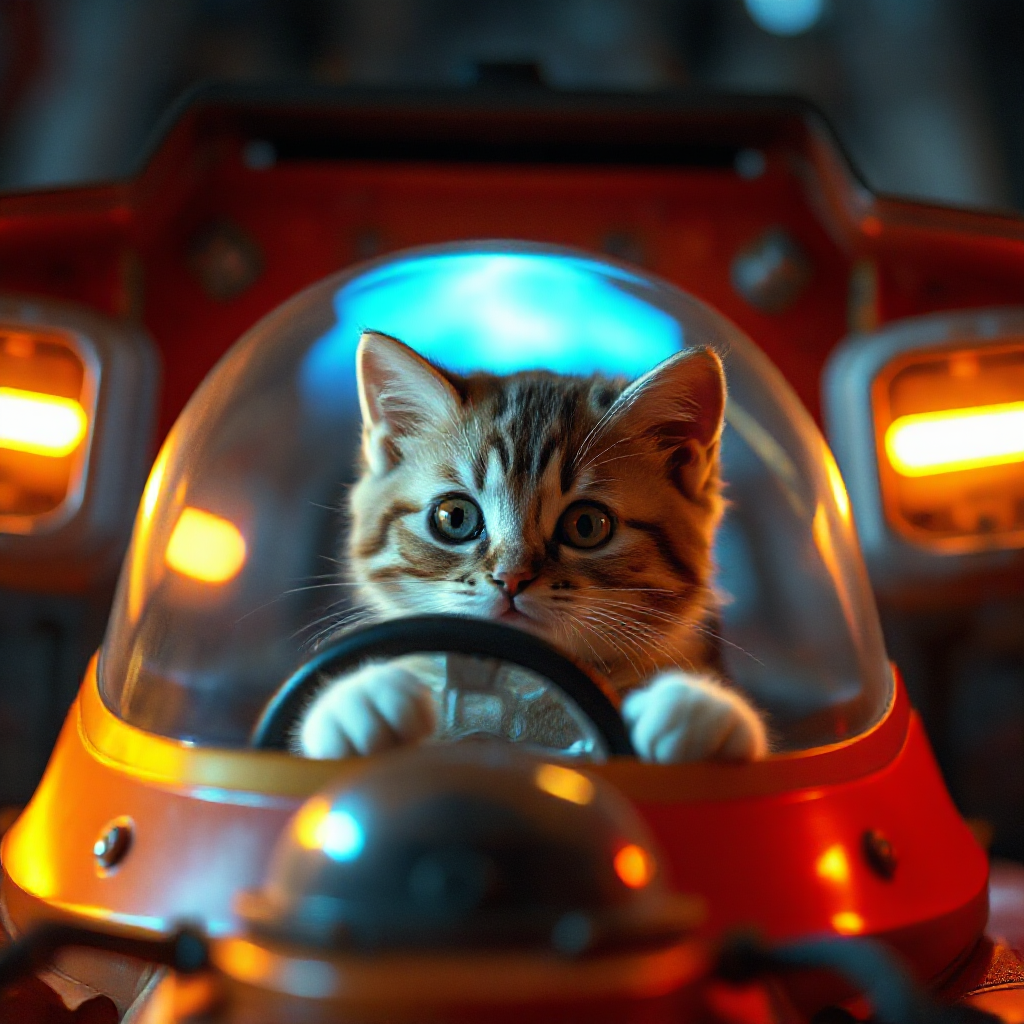

In [37]:
# --- /v1/images/generations: text-to-image (FLUX.1-schnell) ---
# First call boots sd-server on demand and unloads chat/audio/embedding
# (VRAM guard). Response is OpenAI-style {created, data:[{b64_json}]}.
t0 = time.perf_counter()
r = httpx.post(f"{BASE_URL}/v1/images/generations", json={
    "model": IMAGE_MODEL, "prompt": IMAGE_PROMPT, "size": IMAGE_SIZE, "n": 1,
}, timeout=WARMUP_TIMEOUT_S)
lat = time.perf_counter() - t0

png = None
ok = r.status_code == 200
if ok:
    try:
        b64 = r.json()["data"][0]["b64_json"]
        png = base64.b64decode(b64)
        ok = png[:8] == bytes.fromhex("89504e470d0a1a0a")  # PNG magic bytes
    except (KeyError, IndexError, TypeError, ValueError):
        ok = False

check("POST /v1/images/generations", ok, f"{r.status_code} {r.text[:160]}")
if png:
    sample = OUT_DIR / f"image_{IMAGE_MODEL}.png"
    sample.write_bytes(png)
    print(f"    {len(png)/1024:.1f} KB PNG saved -> {sample}")
print(f"    latency {lat:.2f}s (includes on-demand boot + generation)")
from IPython.display import Image, display
display(Image(data=png, format='png'))

saved test_output/image_flux_curl.png


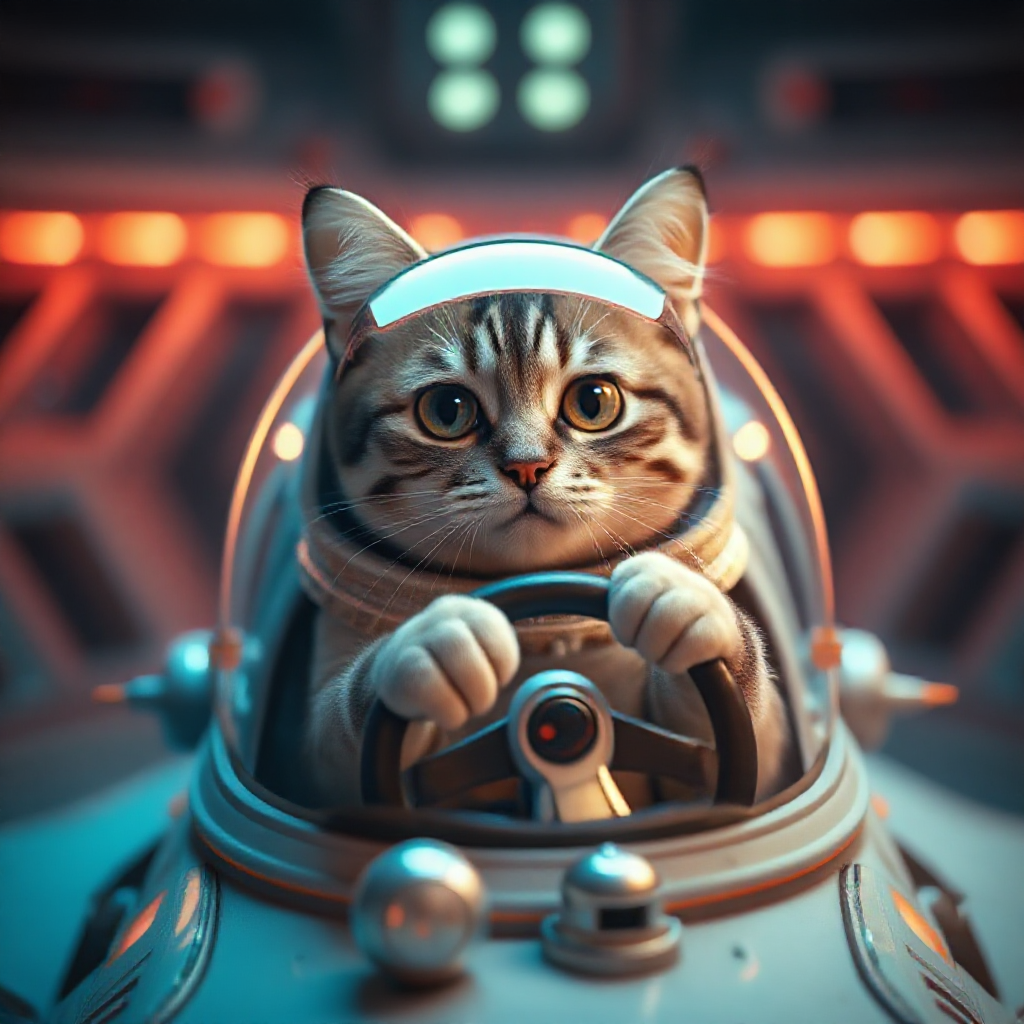

In [39]:
# ad-hoc curl — raw response is OpenAI-style JSON `{created, data:[{b64_json}]}`;
# decode the base64 field to save a PNG.
!curl -s http://localhost:11434/v1/images/generations -X POST -H "Content-Type: application/json" -d '{"model": "flux-schnell", "prompt": "a cat piloting a tiny spaceship, cinematic lighting", "size": "1024x1024", "n": 1}' -o test_output/image_flux_raw.json && python3 -c 'import json,base64; d=json.load(open("test_output/image_flux_raw.json")); open("test_output/image_flux_curl.png","wb").write(base64.b64decode(d["data"][0]["b64_json"])); print("saved test_output/image_flux_curl.png")'
from IPython.display import Image, display
display(Image(filename="test_output/image_flux_curl.png"))

## 15. Final summary

In [40]:
summary()
print()
print("stress knobs used:")
print(f"  BASE_URL:              {BASE_URL}")
print(f"  iterations / conc:     {STRESS_ITERATIONS} / {STRESS_CONCURRENCY}")
print(f"  tts model:             {TTS_MODEL}")
print(f"  asr models:            {ASR_MODEL}, {ASR_AUDIOCPP}")
print(f"  asr stress file:       {ASR_STRESS_FILE} ({ASR_STRESS_FILE.stat().st_size/1024:.0f} KB)")
print(f"  image model:           {IMAGE_MODEL}")



26/29 tests passed
failures:
  - POST /v1/audio/speech (wav): 409 bytes=171 application/json
  - POST /v1/audio/speech (mp3): 409 magic=b'{"er'
  - POST /v1/audio/speech (clone: qwen3-tts): 409 bytes=171

stress knobs used:
  BASE_URL:              http://127.0.0.1:11434
  iterations / conc:     32 / 8
  tts model:             supertonic-3
  asr models:            whisper-asr, qwen3-asr
  asr stress file:       /home/adnathan/llamaswap/data/script_scarlette_ref.wav (219 KB)
  image model:           flux-schnell
